In [3]:
%load_ext autoreload
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

%autoreload 2
from panoseti_interface import PanosetiRun

# Usage
test_out_dir = Path("out")
data_dir = Path("data")
run_dir = "obs_UCB_lab.start_2026-03-03T18:33:50Z.runtype_eng-interleave.pffd"

# 1. Load the Run
run_path = data_dir / run_dir
try:
    run = PanosetiRun(run_path)
except FileNotFoundError:
    print("Run directory not found, check path.")
    exit(1)

print("Available Products:", run.list_products())
run.show()
# Expected: ['dp_ph1024.bpp_2.module_253', 'dp_ph1024.bpp_2.module_252', ...]
print(run.configs["sw_info"])

Available Products: ['dp_img16.bpp_2.module_254', 'dp_img8.bpp_1.module_254', 'dp_ph1024.bpp_2.module_254']


Run: obs_UCB_lab.start_2026-03-03T18:33:50Z.runtype_eng-interleave.pffd
├── Configurations
│   ├── quabo_config_192.168.3.250.json
│   ├── daq_config.json
│   ├── quabo_config_192.168.3.251.json
│   ├── quabo_ph_baseline.json
│   ├── obs_config.json
│   ├── sw_info.json
│   ├── data_config.json
│   ├── quabo_config_192.168.3.248.json
│   ├── network_config.json
│   ├── quabo_uids.json
│   └── quabo_config_192.168.3.249.json
└── Data Products
    ├── dp_ph1024.bpp_2.module_254 (57,093 frames)
    ├── dp_img16.bpp_2.module_254 (4,369 frames)
    └── dp_img8.bpp_1.module_254 (7,100 frames)

{'commit': '5aa3d77553aae9e72e2998914a5eae6489992b55', 'author': 'Nicolas Rault-Wang', 'branch': 'add-interleaving', 'commit_date': '2026-03-03 09:38:28'}


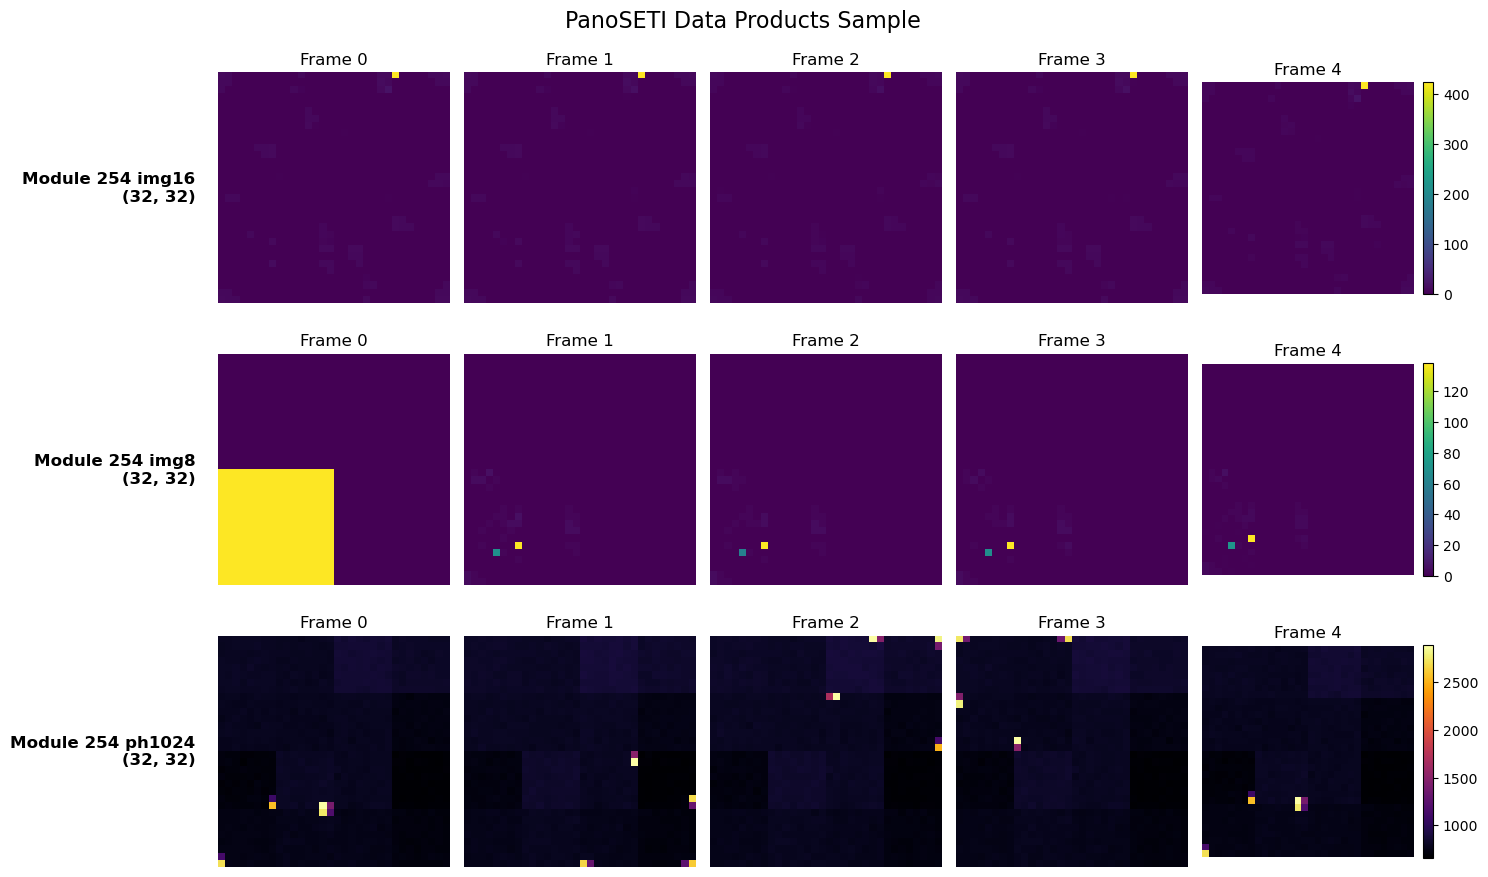

In [4]:
# import matplotlib.pyplot as plt
# from pathlib import Path
# from panoseti_interface import PanosetiRun
import seaborn as sns

# # Initialize the Run
# run_path = Path("data/obs_UCB_lab.start_2026-03-03T18:33:50Z.runtype_eng-interleave.pffd")
# run = PanosetiRun(run_path)

products = run.list_products()
frames_per_product = 5

# Set up the Matplotlib Grid
fig, axes = plt.subplots(
    nrows=len(products), 
    ncols=frames_per_product, 
    figsize=(3 * frames_per_product, 3 * len(products)),
    squeeze=False
)

fig.suptitle("PanoSETI Data Products Sample", fontsize=16, y=0.98)

for row_idx, prod_name in enumerate(products):
    seq = run.get_product(prod_name)
    
    # Grab the first 5 frames
    count = min(frames_per_product, len(seq))
    if count == 0:
        continue
        
    image_stack = seq.get_image_array(start=0, count=count)
    fmt_name = f"Module {seq.meta['module']} {seq.frame_config.format_name}"
    # print(fmt_name)
    
    for col_idx in range(frames_per_product):
        ax = axes[row_idx, col_idx]
        if col_idx < count:
            img = image_stack[col_idx]
            
            # Use 'viridis' for general images, 'inferno' or 'magma' can look better for pulse heights
            cmap = 'inferno' if 'ph' in fmt_name else 'viridis'
            im = ax.imshow(img, cmap=cmap, origin='lower')
            
            ax.set_title(f"Frame {col_idx}")
            ax.axis('off')
            
            # Add a colorbar to the last plot in the row to interpret intensities
            if col_idx == frames_per_product - 1:
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        else:
            # Hide empty subplots if a product has fewer than 5 frames
            ax.axis('off')

    # Label the row with the product name and shape
    axes[row_idx, 0].text(-0.1, 0.5, f"{fmt_name}\n{seq.frame_config.image_shape}", 
                          transform=axes[row_idx, 0].transAxes, 
                          va='center', ha='right', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(left=0.15) # Leave room for row labels
plt.show()